<img src="https://www.nlab.org.uk/wp-content/uploads/nlabmain.png" style="width:40%; clear:both; margin-bottom:-20px" align=left>
<br style="clear:both;"/>

## Analytics Specializations & Applications - Week 7

# Text Analytics
----------
Dr Georgiana Nica-Avram - University of Nottingham
[mail](mailto:georgiana.nica-avram1@nottingham.ac.uk)
[web](http://www.neodemographics.org)

There is a growing specialization in business analytics that is concerned with Text Analysis and natural language processing (NLP), as it allows businesses to interrogate the mass of unstructured data that exists about their customers, products and interactions - data that far outweighs the "structured" datasets we have considered up to now.

However, analysing such data is non-trivial. Computers are good at understanding rigidly-structured data with limited variety. However, when we deal with unstructured free-form text, things begin to get difficult.

Some of the most common applications of NLP include sentiment analysis, topic modeling, part-of-speech tagging, entity recognition, and so on. The goal of NLP is to develop a set of algorithms so that a company can interact with text written in plain English to use some of the outputs in their businesses processes. We are going to explore how to do this below, in the context of BlueSky posts from a leading publication on emerging technology news and insights.

# Task 7.1 Setting up your Bluesky account

If you need to scrape private data, search more aggressively, or perform actions (like liking a post), you need a "session". Start by creating an "App Password" in your Bluesky settings first.

In [11]:
import requests
import pandas as pd
from datetime import datetime, UTC
import time

# Configuration & Authentication
HANDLE = "shreyuu-dev.bsky.social"                                              # replace 'handle' with the account name you chose on Bluesky
APP_PASSWORD = "osip-pbxt-xnfz-52kf"                                            # Generate this in Settings, App Passwords
BASE_URL = "https://bsky.social/xrpc"

def get_session():

    resp = requests.post(
        f"{BASE_URL}/com.atproto.server.createSession",
        json={"identifier": HANDLE, "password": APP_PASSWORD}
    )
    resp.raise_for_status()
    return resp.json()

# The Authenticated Scraper
def scrape_bluesky_full_access(target_handle, max_pages=10):
    session = get_session()
    headers = {"Authorization": f"Bearer {session['accessJwt']}"}

    all_posts = []
    cursor = None

    for page in range(max_pages):
        params = {
            "actor": target_handle,
            "limit": 50,                                                        # Authenticated limit is usually higher
        }
        if cursor:
            params["cursor"] = cursor

        url = f"{BASE_URL}/app.bsky.feed.getAuthorFeed"
        response = requests.get(url, params=params, headers=headers)

        if response.status_code == 401:                                         # This means your token expired
            session = get_session()
            headers = {"Authorization": f"Bearer {session['accessJwt']}"}
            continue

        data = response.json()
        feed = data.get('feed', [])

        for item in feed:                                                       # These are the post details we are harvesting
            post = item.get('post', {})
            all_posts.append({
                "cid": post.get('cid'),
                "text": post.get('record', {}).get('text'),
                "created_at": post.get('record', {}).get('createdAt'),
                "reply_count": post.get('replyCount'),
                "repost_count": post.get('repostCount'),
                "like_count": post.get('likeCount')
            })

        cursor = data.get('cursor')
        if not cursor:
            break

        print(f"Scraped {len(all_posts)} posts so far...")
        time.sleep(0.5) # Authenticated requests can be faster

    return pd.DataFrame(all_posts)

df = scrape_bluesky_full_access("technologyreview.com")                         # This is the name of the account we are scraping

Scraped 50 posts so far...
Scraped 100 posts so far...
Scraped 150 posts so far...
Scraped 200 posts so far...
Scraped 250 posts so far...
Scraped 300 posts so far...
Scraped 350 posts so far...
Scraped 399 posts so far...
Scraped 449 posts so far...
Scraped 499 posts so far...


In [12]:
# Make sure to save your dataframe locally so that you don't have to scrape the data all over again.

df.to_csv(r'...\bluesky_posts.csv', sep = ',', header = True)

# Task 7.2 Basic text statistics

Let's have a look at some basic text statistics, such as the number of words in each post. Micro-blogging platforms such as Bluesky often have short-lenght posts. This simple statistic will inform your choice of algorithms later on in the analysis.

We have collected 499 posts.
count    499.000000
mean      25.735471
std       11.603652
min        3.000000
25%       16.000000
50%       24.000000
75%       35.000000
max       54.000000
Name: post_word_count, dtype: float64


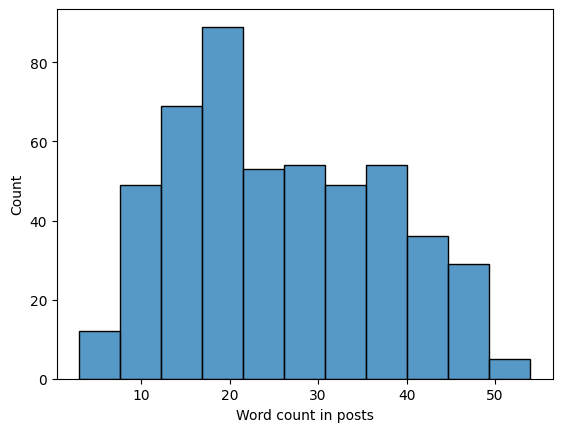

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.set_index('cid')
df['post_word_count']= df['text'].str.split().str.len()

print(f"We have collected {len(df)} posts.")
print(df['post_word_count'].describe())
sns.histplot(df['post_word_count'])
plt.xlabel('Word count in posts')
plt.show()

# Task 7.3 Advanced text statistics

We start by splitting our posts into sentences and words, and removing unnecessary characters such as punctuation.

In [ ]:
# Gensim is a Python library for topic modelling, document indexing and similarity retrieval with large corpora. The first step is to install gensim library dependencies.
# !pip install gensim
from gensim import *
import gensim.utils
from gensim.utils import simple_preprocess
from nltk.stem import WordNetLemmatizer
from collections import defaultdict
from pprint import pprint
from six import iteritems
from collections import Counter
from gensim.models import ldaseqmodel, Phrases, Word2Vec
from gensim.models.phrases import Phraser

documents= []
for line in df['text']:
    documents.append(line)

texts= []
for document in documents:
    text= gensim.utils.simple_preprocess(str(document), deacc= True)            # deacc removes punctuation
    texts.append(text)

dictionary= corpora.Dictionary(texts)                                           # The Gensim dictionary contains the mapping of all words, a.k.a tokens, to their unique integer id
corpus= [dictionary.doc2bow(d) for d in texts]

  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached smart_open-7.5.1-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-2.1.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached smart_open-7.5.1-py3-none-any.whl (64 kB)
Using cached wrapt-2.1.2-cp314-cp314-macosx_11_0_arm64.whl (61 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/kf/5c3rzd1n3mg01xt7v99dzfvr0000gn/T/pip-build-env-ecsfgp5m/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/kf/5c3rzd1n3mg01xt7v99dzfvr0000gn/T/pip-build-env-ecsfgp5m/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:2

ModuleNotFoundError: No module named 'gensim'

Number of unique tokens: 3254
Number of documents: 499


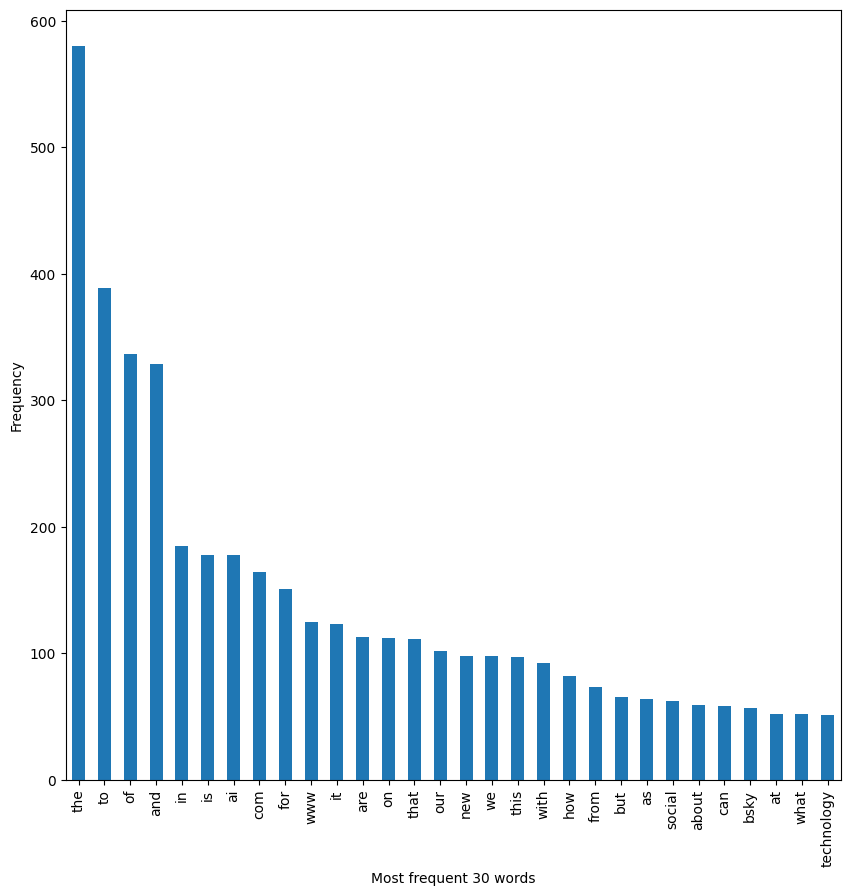

In [ ]:
# The next step is to visualise the most common 30 words

from collections import Counter

print('Number of unique tokens: %d' % len(dictionary))
print('Number of documents: %d' % len(corpus))

# Frequency table
freq = Counter(t for text in texts for t in text)
word_freq = (
    pd.DataFrame(freq.items(), columns=['token','freq'])
    .query('token in @dictionary.token2id')
)

# Top 30 plot
top30 = word_freq.nlargest(30, 'freq')

top30.plot(kind='bar', x='token', y='freq', legend=False, figsize=(10,10))
plt.xlabel('Most frequent 30 words')
plt.ylabel('Frequency')
plt.xticks(rotation=90)

# Rank all tokens
sorted_freq = word_freq.sort_values('freq', ascending=False).assign(rank=lambda d: range(1, len(d)+1))

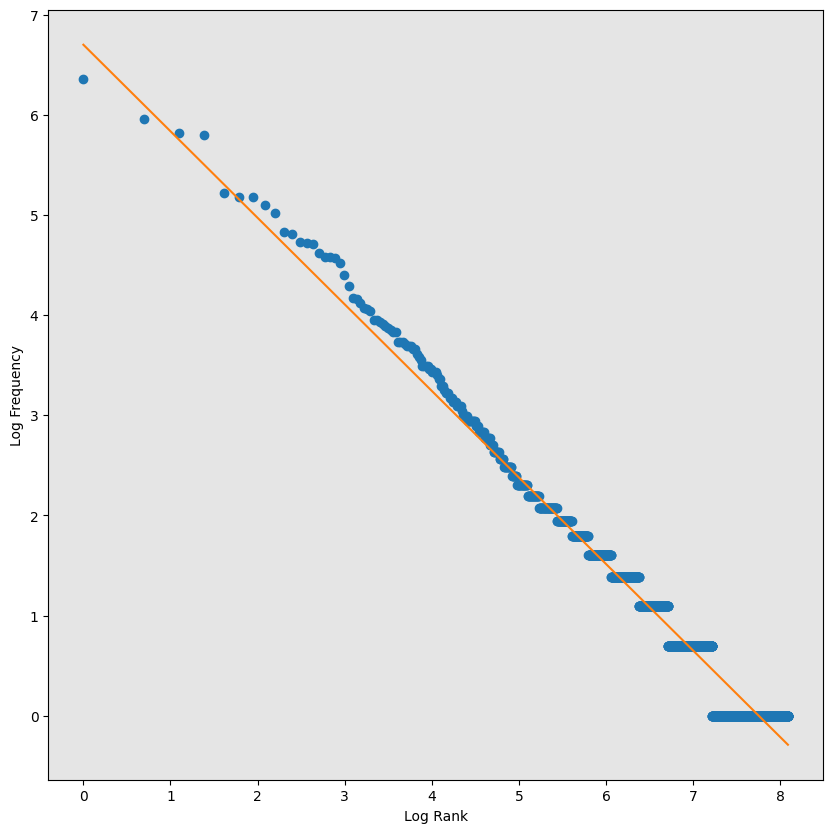

Slope -0.86 Intercept 6.7 r-value -0.98 r^2 value 0.96 p-value 0.0 Standard error 0.0


In [ ]:
# Log-log plots of word rank versus frequency visualize Zipf's law, which states that word frequency is inversely proportional to its rank.
# On a logarithmic scale, this relationship appears as a straight line with a slope of approximately -1, where a few words are extremely common, and most are rare.
# As we saw earlier, the most common words in this corpus are articles (stop words) - often not informative for understanding the topics discussed in the posts.
# We will deal with stop words in the next tasks.

import numpy as np
from scipy import stats

log_rank= np.log(sorted_freq['rank'])
log_frequency= np.log(sorted_freq['freq'])

slope, intercept, r_value, p_value, std_err= stats.linregress(log_rank, log_frequency)
line= slope*log_rank+intercept

fig, ax= plt.subplots(figsize= (10, 10))
plt.plot(log_rank, log_frequency, 'o', log_rank, line)
ax= plt.gca()
ax.set_facecolor((0.898, 0.898, 0.898))
fig= plt.gcf()
ax.set_xlabel('Log Rank')
ax.set_ylabel('Log Frequency')
plt.show()

print('Slope', np.round(slope, 2), 'Intercept', np.round(intercept, 2), 'r-value', np.round(r_value, 2), 'r^2 value', np.round(r_value**2, 2), 'p-value', np.round(p_value, 4), 'Standard error', np.round(std_err, 2))

# Task 7.4 Topic modeling with BERTopic

Imagine reading 1,000 customer reviews and instantly seeing themes emerge — not just based on repetitive words, but actual concepts. That’s BERTopic.

BERTopic is a modern out of the box topic modeling framework that addresses many limitations of traditional approaches by:

1. using transformer-based embeddings (like BERT) to understand the semantic meaning of documents
2. representing documents using Class-based TF-IDF (c-TF-IDF) to highlight important words per topic by comparing them against the entire dataset, improving topic interpretability
3. clustering them based on their context rather than just word frequency

An important advantage of BERTopic is that it requires almost no preprocessing of the given texts. Unlike LDA, however, BERTopic assumes each document contains only one topic.

In [ ]:
# !pip install bertopic
from sentence_transformers import SentenceTransformer
import bertopic
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

# Load a custom embedding model
# all-MiniLM-L6-v2 is a fast sentence-transformer model that maps sentences and paragraphs into a 384-dimensional dense vector space.
# It is primarily used for semantic search, text clustering, and similarity matching, offering high performance for tasks requiring semantic understanding.
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Fine-tune topic representation
# In BERTopic, there are a number of different topic representations that we can choose from.
# A great start is KeyBERTInspired, which for many users increases the coherence and reduces stopwords from the resulting topic representations.
representation_model = KeyBERTInspired()

# Pass it into BERTopic
posts = df['text'].to_list()

topic_model = BERTopic(embedding_model=embedding_model, min_topic_size = 10, representation_model = representation_model)
topics, probs = topic_model.fit_transform(posts)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 15.7 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 14.7 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 14.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.2 MB/s  0:00:00 eta 0:00:01
  Created wheel for hdbscan: filename=hdbscan-0.8.41-cp314-cp314-macosx_26_0_arm64.whl size=729444 sha256=f1b77ae2473c8989b7838f6d8d7037870a3a65a7f77fbdfbf698037b3ee95690
  Stored in directory: /Users/shreyu/Library/Caches/pip/wheels/86/1d/de/2234543f644a34649a430567dd4f49b4501e45c47111283c5c
Successfully built hdbscan
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [bertopic]8/9 [bertopic]transformers]


/Users/shreyu/VSCODE/junk/UoN-Business-Analytics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# After generating topics and their probabilities, we can access the frequent topics that were generated, including a topic name and most representative posts for that topic.
topic_labels = topic_model.generate_topic_labels(nr_words = 3, topic_prefix = False, word_length = 15, separator = "_")
topic_model.set_topic_labels(topic_labels)

# Topic -1 refers to all outliers and should typically be ignored.
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic  Count                                               Name  \
0     -1     69       -1_technologyreview_ai_technology_innovators   
1      0    205          0_ai_technologyreview_chatbots_technology   
2      1     84                  1_emissions_redwood_fuels_climate   
3      2     79  2_technology_technologies_technologyreview_bre...   
4      3     28           3_mars_technologyreview_alien_technology   
5      4     20    4_technologies_technologyreview_breakthrough_ai   
6      5     14          5_breakthrough_advances_technologies_most   

                                  CustomName  \
0              technologyrevie_ai_technology   
1                ai_technologyrevie_chatbots   
2                    emissions_redwood_fuels   
3    technology_technologies_technologyrevie   
4                 mars_technologyrevie_alien   
5  technologies_technologyrevie_breakthrough   
6         breakthrough_advances_technologies   

                                      Representation  

In [ ]:
!pip install WordCloud

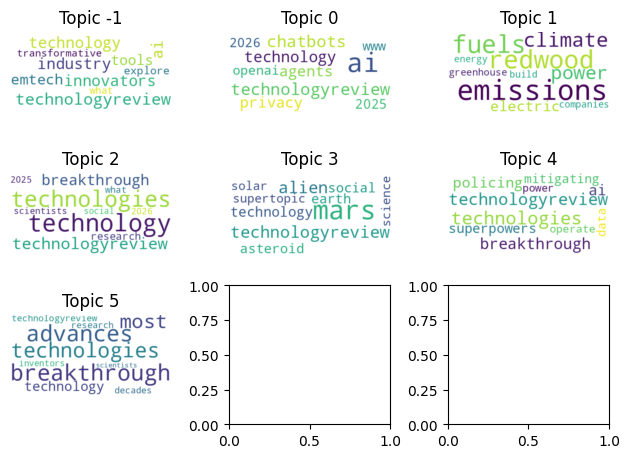

In [ ]:
# An informative way of visualising topic distributions over words is through wordclouds
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

# Get all valid topic IDs
top_topics = topic_model.get_topic_info()['Topic'].tolist()

cols = 3
rows = math.ceil(len(top_topics) / cols)

fig, axes = plt.subplots(rows, cols)
axes = axes.flatten()

for i, topic_id in enumerate(top_topics):
    topic_words = {word: score for word, score in topic_model.get_topic(topic_id)}
    wc = WordCloud(background_color="white").generate_from_frequencies(topic_words)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Topic {topic_id}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Find the most relevant topic for the word "AI".
topic_ids, similarity_scores = topic_model.find_topics("AI", top_n = 1)

# Output the results
print("Topic IDs: ", topic_ids, "Similarity Scores: ", similarity_scores)

# Inspect the topic's keywords
topic_keywords = topic_model.get_topic(topic_ids[0])
print(f"Keywords for topic {topic_ids[0]}: {topic_keywords}")

Topics resulting from topic modeling are often evaluated in terms of coherence.

Topic coherence is simply a proxy for "does this topic have a clear, singular theme?" Though the consensus is that high coherence score is useless if the words don't make sense to a human.

Two foundational readings for understanding how coherence metrics are used in Gensim and BERTopic include:

[Coherence models](https://radimrehurek.com/gensim/models/coherencemodel.html)

[Exploring the Space of Topic Coherence Measures](https://dl.acm.org/doi/10.1145/2684822.2685324)


In [ ]:
# Using .get_document_info, we can also extract information on a document level, such as their corresponding topics, probabilities and whether they are representative documents for a topic:
document_info = topic_model.get_document_info(posts)
print(document_info.head(10))

# Task 7.5 Topic modeling with LDA
Before we test an alternative topic modeling approach, we need to get our data into shape. As we saw earlier, many of the words in the corpus are not informative. So we start by cleaning the posts.


## Task 7.5.1 Cleaning the posts

In [ ]:
import re
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('wordnet')
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, sent_tokenize
from textblob import Word

# Cleaning the posts by converting to lower case and removing punctuation and digits, replacing accentuated characters
def cleanText(text):
        text= re.sub(r"[^\w\s]", " ", str(text)) #remove punctuation
        text= re.sub(r"\d+", "", str(text))     #remove digits
        text= re.sub(r"\b[a-zA-Z]\b", "", str(text)) #remove one-letter words
        text= text.lower()
        text= re.sub(u"[àáâãäå]", 'a', str(text))
        text= re.sub(u"[èéêë]", 'e', str(text))
        text= re.sub(u"[ț]", 't', str(text))
        return text
# Stopwords
stop= stopwords.words('english')

# Lemmatization - reduces inflected words to their base or dictionary form, known as a lemma.
lemmatizer= WordNetLemmatizer()

df['text_clean']= df['text'].apply(cleanText)
df['text_clean']= df['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
df['text_clean']= df['text_clean'].apply(lambda x: ' '.join([Word(word).lemmatize() for word in x.split()]))

# Data lists
documents_clean= []
for line in df['text_clean']:
    documents_clean.append(line)

texts_clean= []
for document in documents_clean:
    text= gensim.utils.simple_preprocess(str(document), deacc= True) #deacc removes punctuation
    texts_clean.append(text)


We cleaned our posts of redundant words and characters. Now it's time to convert them in a numeric format. We use the "bag of words" approach and describe each post with no regards to the ordering of the words, but simply their counts. This turns out to still be a very powerful and flexible approach, allowing us to compare the similarity between two pieces of text.

To do this we use a "Vector Space" representation of a document. First we consider every word that can appear in a corpus (i.e., across all the BlueSky posts we have) as a feature in its own right. We then simply assign the value of that feature for any individual document, as the number of times that word appears. This means if we have M words in our "dictionary" of words that appear across the corpus, each document can be represented by M features, and we are back in our tradiaional home of seeing a document as a point in an M-dimensional space.

By way of example consider an example (highly condensed!) universe where the are only 3 possible words: "Apple", "Orange" and "Banana". Every sentence of document is made out of them. In this case every document can be represented in a 3 dimensional space. Each word is an axis of that space:

Apple --> [1,0,0]

Banana --> [0,1,0]

Orange --> [0,1,0]

Then a sentence or a document is simply a linear combination of these vectors, where the number of times that word appears is the coefficient along that dimension. For example consider:

dM = "Banana Apple Orange" --> [1, 1, 1]

d1 = "Banana Apple Banana Banana Banana Apple" --> [2, 4, 0]

d2 = "Banana Orange Banana Banana Orange Banana" --> [0, 4, 2]

d3 = "Apple Orange Orange Apple" --> [2, 0, 2]

d4 = "Apple Banana Apple Banana" --> [2, 2, 0]

d5 = "Banana Apple Banana Banana Orange Banana" --> [1, 4, 1]

In [ ]:
# Dictionary and corpus after cleaning
dictionary_clean= corpora.Dictionary(texts_clean) #dictionary
dictionary_clean.filter_extremes(no_below= 3, no_above= 0.95)
corpus_clean= [dictionary_clean.doc2bow(d) for d in texts_clean]

print('Number of unique tokens: %d' % len(dictionary_clean))
print('Number of documents: %d' % len(corpus_clean))

line_clean= []
for line in df['text_clean']:
    documents_clean.append(line)
    line_clean.append(len(line))
print('Maximum number of words in a document: %d' % max(line_clean))
print('Mean number of words in a document: %d' % np.mean(line_clean))
print('Minimum number of words in a document: %d' % min(line_clean))

#---------------------
# Frequency table
freq = Counter(t for text in texts_clean for t in text)
word_freq = (
    pd.DataFrame(freq.items(), columns=['token','freq'])
    .query('token in @dictionary.token2id')
)

# Top 30 plot
top30 = word_freq.nlargest(30, 'freq')

top30.plot(kind='bar', x='token', y='freq', legend=False, figsize=(10,10))
plt.xlabel('Most frequent 30 keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=90)


## Task 7.5.2 Sentiment analysis

Now let's use our preprocessed posts to do some sentiment analysis.

Polarity measures the emotional tone of text, classifying it as positive, negative, or neutral. It typically uses a score ranging from -1.0 (very negative) to +1.0 (very positive), with 0 indicating neutral.

TextBlob’s subjectivity score measures the amount of personal opinion, emotion, or judgment in a text, ranging from 0.0 (very objective/factual) to 1.0 (very subjective/opinion-based).

These metrics are crucial for analyzing user reviews, social media, and market trends.

In [ ]:
import textblob
from textblob import TextBlob

# We calculate the polarity and subjectivity of each post
def detect_pol(text):
    return TextBlob(text).sentiment.polarity
df['polarity']= df['text_clean'].apply(detect_pol)

def detect_sub(text):
    return TextBlob(text).sentiment.subjectivity
df['subjectivity']= df['text_clean'].apply(detect_sub)


In [ ]:
df['polarity'].describe()

In [ ]:
df['subjectivity'].describe()

## Task 7.5.3: Topic modeling with LDA

In previous sessions, we used LDA to identify "shopping missions" from the items found in shopping baskets. We extent the idea of "bag of words" to BlueSky to represent in vector space the posts we collected. Unlike BERTopic, LDA gives better results on preprocessed text, and passes it on to gensim's LdaModel which handles corpora of text very well.

Another difference is that LDA is a probabilistic model that assumes each topic is a mixture over an underlying set of words, and each document is a mixture of over a set of topic probabilities (not just one topic).

In [ ]:
from gensim.models import LdaModel

tfidf= models.TfidfModel(corpus_clean)
tfidf_corpus= tfidf[corpus_clean]

lda_model= gensim.models.ldamodel.LdaModel(corpus= corpus_clean,
                                           id2word= dictionary_clean,
                                           num_topics= 6,
                                           random_state= 42,
                                           update_every= 1,
                                           chunksize= 100,
                                           passes= 10,
                                           alpha= 5/6,
                                           per_word_topics= True)

In [ ]:
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim  # don't skip this

pyLDAvis.enable_notebook()
vis= pyLDAvis.gensim.prepare(lda_model, corpus_clean, dictionary_clean)
vis

In [ ]:
num_topics = lda_model.num_topics

cols = 3
rows = math.ceil(num_topics / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.flatten()

for i in range(num_topics):
    topic_words = dict(lda_model.show_topic(i, topn=100))

    wc = WordCloud(background_color='white').generate_from_frequencies(topic_words)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Topic {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
dtl= []
for n in range(len(corpus_clean)):
    dt= lda_model.get_document_topics(corpus_clean[n], minimum_probability= 0.0)
    dtl.append(x[1] for x in dt)

labels= []
for l in range(num_topics):
    labels.append(f'Topic {l}')

docs_topics_df= pd.DataFrame.from_records(dtl, columns= labels, index= df.index)

df = df.reset_index().merge(docs_topics_df.reset_index(), how = 'inner', right_on = 'cid', left_on = 'cid')

In [ ]:
# Heatmaps provide a clear visual representation of how strongly variables are correlated.
matrix = df[['reply_count', 'repost_count',
       'like_count', 'post_word_count', 'polarity','subjectivity',
       'Topic 0', 'Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5']].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()